In [37]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split,GridSearchCV,learning_curve
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix, classification_report, roc_auc_score, roc_curve,ConfusionMatrixDisplay,precision_recall_curve
)

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)


In [2]:
df=pd.read_csv("C:/Users/ASUS/Downloads/hotel_bookings.csv/hotel_bookings.csv")

In [3]:
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


### **Problem Framing, Splits & Leakage (Hotel Booking Dataset)**

##### Our ML Problem (Formalized)

Task: Binary classification
Target: is_canceled
Positive class (1): Booking gets canceled
Negative class (0): Booking is honored (not canceled)

This framing matters because:
Business interpretation: Predict risk of cancellation before arrival
Actionability: Overbooking strategy, deposit policy, pricing, reminders, etc.
Evaluation metrics: Recall for canceled class might matter more than raw accuracy.

##### Target Leakage: The Silent Killer 
What is Leakage?
Leakage = using information that would not be available at prediction time.
In this dataset, many columns are post-booking outcomes, not pre-booking signals.
Examples of dangerous leakage features:-

| Column                    | Why it leaks                                  |
| ------------------------- | --------------------------------------------- |
| `reservation_status`      | Literally tells you if it was canceled        |
| `reservation_status_date` | Timestamp of outcome                          |
| `assigned_room_type`      | Changes after booking                         |
| `booking_changes`         | Often influenced by cancellation process      |
| `deposit_type`            | Might be okay, but depends on business timing |
| `agent`, `company`        | Often missing; can encode future behavior     |
| `days_in_waiting_list`    | Depends on hotel’s internal handling          |

If you include reservation_status, your model will get 99% accuracy and be 100% useless in real life.

Leakage Rule (Golden Rule) :
Only include features that are known at the time of booking, not after the booking evolves.

In [4]:
target='is_canceled'
Leaky_Features=['reservation_status','reservation_status_date']
X=df.drop(columns=[target]+Leaky_Features)
y=df[target]

Scikit-learn does not have a single function that splits into three sets at once. You have to do it in two "rounds" or "stages."

**Round 1:**  The "Vault" SplitFirst, you take your entire dataset and set aside a piece that you lock in a "vault." This is your Test Set.You split the data into 80% (Train + Val) and 20% (Test).Purpose: The Test set is the "Final Exam." You are not allowed to look at it, touch it, or use it to tune your model. If you use it to make decisions, you are "cheating" (Data Leakage).

**Round 2:** The "Practice" SplitNow, you take that 80% you kept and split it again.You take 25% of that 80% (which equals 20% of the original total).This gives you: 60% Train and 20% Validation.Purpose: The Validation set is your "Practice Exam." You use this to see if your Logistic Regression is overfitting or if you need to change your $C$ parameter (Regularization).

In [5]:
X['arrival_date_year']=X['arrival_date_year'].astype(str)
X['agent'] = X['agent'].astype(str)
X['company'] = X['company'].astype(str)
top_5_countries=X['country'].value_counts().nlargest(5).index
X['country']=X['country'].apply(lambda x: x if x in top_5_countries else 'other')

In [6]:
X_train_val,X_test,y_train_val,y_test=train_test_split(X,y,test_size=0.20,stratify=y,random_state=42)
X_train,X_val,y_train,y_val=train_test_split(X_train_val,y_train_val,test_size=0.25,stratify=y_train_val,random_state=42)

**Final split:**
60% Train
20% Validation
20% Test

**Why stratify?**
Because cancellations are imbalanced.
Without stratification, you may end up with a test set with a totally different cancel ratio → misleading metrics.

### **Building Pipeline**

In [7]:
num_features=['lead_time','stays_in_weekend_nights','arrival_date_day_of_month','adults','children','babies','adr','total_of_special_requests','previous_bookings_not_canceled','previous_cancellations']
bin_features=['is_repeated_guest']
cat_features=['hotel','arrival_date_year','arrival_date_month','meal','distribution_channel','reserved_room_type','deposit_type','country']
print(num_features)

['lead_time', 'stays_in_weekend_nights', 'arrival_date_day_of_month', 'adults', 'children', 'babies', 'adr', 'total_of_special_requests', 'previous_bookings_not_canceled', 'previous_cancellations']


1. **The Sub-Pipelines** (The Streams)
We first create specialized Pipelines for each data type (num, bin, cat). A Pipeline is a sequence of transformations. For example, our num_pipeline first fills missing values using the Median (Imputation) and then scales the features so they have a mean of 0 and a variance of 1 (StandardScaler). This ensures that a feature like lead_time (0–300) doesn't "overpower" a feature like adults (1–4) just because its numbers are larger.

In [8]:
num_pipeline=Pipeline([
    ('imputer',SimpleImputer(strategy='median')),
    ('scaler',StandardScaler())    
])
bin_pipeline=Pipeline([
    ('imputer',SimpleImputer(strategy='constant',fill_value=0))
])
cat_pipeline=Pipeline([
    ('imputer',SimpleImputer(strategy='most_frequent')),
    ('encoder',OneHotEncoder(handle_unknown='ignore',sparse_output=False))
])

2. **The ColumnTransformer** (The River)
Since different columns require different "treatments," we use a ColumnTransformer. Think of this as a traffic controller. We tell it: "Apply the num_pipeline only to these 10 numerical columns, apply the cat_pipeline (One-Hot Encoding) only to these categorical columns, and leave the binary ones as they are." This creates a single, unified object that can process a whole raw DataFrame in one go.

In [9]:
preprocessor=ColumnTransformer(
    transformers=[
        ('continuous_num',num_pipeline,num_features),
        ('binary_num',bin_pipeline,bin_features),
        ('categorical',cat_pipeline,cat_features)
    ],
    remainder='drop'
)

3. **The Fit vs. Transform Logic** (The Concept)
This is the most critical rule in Machine Learning:

 *.fit_transform(X_train)*  : We only "Fit" on the training data. This is where the model learns the internal parameters—like the specific median of adr or the unique categories in country. It then transforms the training data using these learned values.

*.transform(X_val / X_test)* : We only transform the validation and test sets. We do not re-calculate the median or the scaling factors. We use the exact values learned from the training set. This ensures the model is tested on "unseen" data without any "hints" (leakage) from the future.

In [10]:
X_train_processed=preprocessor.fit_transform(X_train)
X_val_processed=preprocessor.transform(X_val)
X_test_processed=preprocessor.transform(X_test)

print(f"Success! Training data now has {X_train_processed.shape[1]} features.")

Success! Training data now has 57 features.


In [11]:
# No missing values?
np.isnan(X_train_processed).sum()

# Same feature dimension across splits?
X_train_processed.shape[1] == X_val_processed.shape[1] == X_test_processed.shape[1]


True

##### Common Preprocessing Mistakes (Real-World) :-

| Mistake                          | Why it breaks LR                   |
| -------------------------------- | ---------------------------------- |
| No scaling                       | Regularization becomes meaningless |
| Fit imputer on full data         | Test leakage                       |
| Dropping rare categories blindly | Model loses signal                 |
| Not using handle_unknown         | Model crashes in prod              |
| Encoding train & test separately | Feature misalignment               |


#### **Final Pipeline**
The Final Pipeline like a "Master Function" or a "Production Assembly Line." ### 1. How the "Master Function" works
When you call final_pipeline.fit(X_train, y_train), the Pipeline object acts as a manager that executes these steps in strict order:

**Step 1 (Preprocessing)**: It takes your raw X_train and runs preprocessor.fit_transform(). It learns the scales, the most frequent categories, and the one-hot encodings.

**Step 2 (The Hand-off)**: It takes the resulting clean, numerical matrix (your 57 features) and passes it directly into the LogisticRegression.fit() function.

**Step 3 (The Memory)**: The Pipeline "remembers" both the cleaning rules and the final model weights as one single unit.

In [12]:
full_pipeline=Pipeline(steps=[
    ('preprocessor',preprocessor),
    ('classifier',LogisticRegression(C=1.0,max_iter=1000,random_state=42))
])

1. In Scikit-Learn, $C$ is the inverse of $\lambda$ ($C = 1/\lambda$).If $C$ is small (e.g., 0.01): Regularization is strong. It’s like a leash on your model, keeping the weights small to prevent overfitting.If $C$ is large (e.g., 100): Regularization is weak. The model is free to fit the training data as closely as possible.

2. max_iter: You are 100% right. This is for the Optimization (Gradient Descent). It tells the computer: "If you haven't found the absolute bottom of the cost function after 1000 steps, stop anyway."

3. random_state: Even though LR is a deterministic math formula, the solvers (like lbfgs) sometimes use a random starting point or "shuffle" data. Setting this to 42 ensures that if you run the code tomorrow, you get the exact same result.

In [13]:
full_pipeline.fit(X_train,y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('continuous_num', ...), ('binary_num', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


This interactive diagram is a Scikit-Learn feature (specifically introduced in version 0.23+) that Jupyter notebooks render beautifully. It is designed to help you verify your "Assembly Line" visually.

It’s a lifesaver when you have 50+ features and multiple pipelines because you can click on each box to see exactly what parameters (like strategy='median') are inside.

In [14]:
y_val_pred=full_pipeline.predict(X_val)

In [15]:
print(f"Validation Accuracy: {full_pipeline.score(X_val, y_val):.4f}")

Validation Accuracy: 0.7937


### **Model Evaluation**

#### **Confusion Matrix:**

True Positives (TP): Guest canceled, and the model correctly predicted it. (Win!)

True Negatives (TN): Guest showed up, and the model correctly predicted it. (Win!)

False Positives (FP): Model said "They'll cancel," but they actually showed up. (The "False Alarm" – you might have sold their room to someone else!)

False Negatives (FN): Model said "They'll show up," but they actually canceled. (The "Sneaky Quitter" – you lost revenue because you didn't overbook).

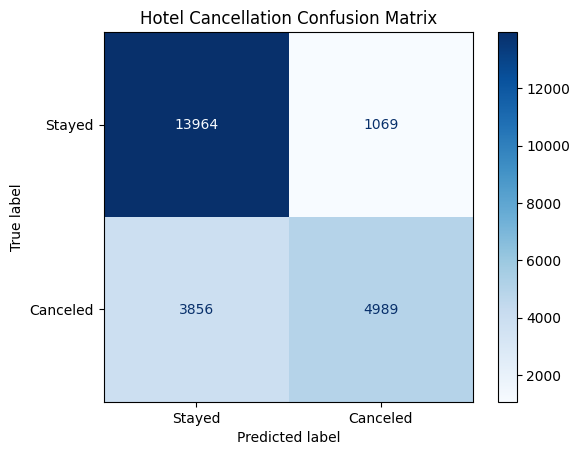

In [16]:
cm=confusion_matrix(y_val,y_val_pred)
disp=ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=['Stayed','Canceled'])
disp.plot(cmap='Blues')
plt.title('Hotel Cancellation Confusion Matrix')
plt.show()

#### **Classification Report**

The Classification Report is the "Dashboard" of your model. While the Confusion Matrix shows you the raw numbers, the report converts those numbers into percentages that tell you exactly how reliable your model is for each class.

**The Classification Report Breakdown**

Precision (The "Certainty" Metric): Of all guests the model predicted would cancel, what percentage actually did?
           
                High Precision = Fewer "False Alarms" for the hotel.

Recall (The "Detection" Metric): Of all the guests who actually canceled, what percentage did the model catch?

                High Recall = Fewer "Sneaky Quitters" (lost revenue).

F1-Score: The harmonic mean of Precision and Recall. Use this if you want a single number that balances both.

Support: The actual number of occurrences of each class in your validation set.

In [17]:
print("Logistic Regression Classification Report:")
print(classification_report(y_val, y_val_pred, target_names=['Stayed', 'Canceled']))

Logistic Regression Classification Report:
              precision    recall  f1-score   support

      Stayed       0.78      0.93      0.85     15033
    Canceled       0.82      0.56      0.67      8845

    accuracy                           0.79     23878
   macro avg       0.80      0.75      0.76     23878
weighted avg       0.80      0.79      0.78     23878



**1. Precision:** The "Certainty" Metric
 Canceled Precision now : 0.82 (82%)

    Precision answers: "If the model predicts a cancellation, how often is it right?"
    The Reality: When your model flags a guest as a "Canceler," it is correct 82% of the time.

*The Business Impact* : This is good! It means the hotel can mostly trust the model. You aren't constantly crying wolf. If you decide to overbook a room based on this prediction, there's only an 18% chance you'll have an angry guest standing in the lobby with no room.

**2. Recall:**  The "Detection" Metric
 Canceled Recall now : 0.56 (56%)

    Recall answers: "Out of all people who actually canceled, how many did we catch?"
    The Reality: This is your "Beast" problem. You are missing 44% of all cancellations. They are slipping through your net and the model is labeling them as "Stayed."

*The Business Impact* : This is bad for revenue. The hotel thinks these 44% are coming, so they keep the rooms empty. Then the guests never show up, the rooms stay empty, and the hotel loses money they could have made by reselling those rooms.

**3. The Trade-off:** Precision vs. Recall
Think of it like a Security Guard at the hotel entrance:

    High Precision Guard: Only stops people who look exactly like a criminal. He rarely stops innocent people (Low False Positives), but some actual criminals might walk right past him (Low Recall).

    High Recall Guard: Stops everyone wearing a hoodie just to be safe. He catches every criminal (High Recall), but he also annoys a lot of innocent guests (High False Positives/Low Precision).

*4. Why is Recall so low now?*

Logistic Regression defaults to a 0.5 threshold. Your model likely sees a lot of "Cancelers" with a probability of 0.4 or 0.45. Because that is less than 0.5, the model "plays it safe" and says they will stay.

How to fix it? We don't need a new algorithm yet. We just need to change the Classification Threshold. If we tell the model: "If the probability of cancellation is > 0.3, flag it," your Recall will go up (you'll catch more), but your Precision will go down (you'll have more false alarms).

#### The Precision-Recall (PR) Curve

We use this to find a threshold without the "brain rush"—exactly.
Instead of you manually typing 0.28, 0.29, 0.30 and re-running the cell, the PR Curve plots every possible threshold on one graph.

The Goal: You want the curve to be as close to the top-right corner as possible (where both Precision and Recall are 1.0).

The Use Case: It is the best tool when you have imbalanced classes (like more "Stayed" than "Canceled"). Since it ignores "True Negatives" (people who stayed and were predicted to stay), it focuses entirely on how well you are handling the "Canceled" class.

##### **Trade-off curve**

This is purely to see the Trade-off. It tells you what is possible (e.g., "Can I get 80% Recall?"), but it doesn't tell you how (the threshold) to get there. It's the "Map" of the terrain.

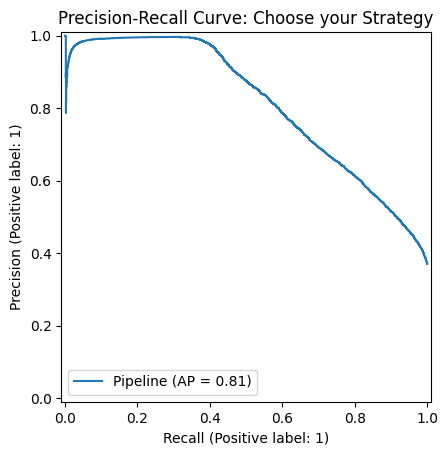

In [18]:
from sklearn.metrics import PrecisionRecallDisplay

# Use the probabilities we talked about
PrecisionRecallDisplay.from_estimator(full_pipeline, X_val, y_val)
plt.title("Precision-Recall Curve: Choose your Strategy")
plt.show()

#### **Precision-Recall curve**
1. This curve is used to find the best threshold for current model.
2. This is the "Control Panel." It tells you exactly where to set the dial to get the result you want. You are correct—this is much more powerful for implementation.

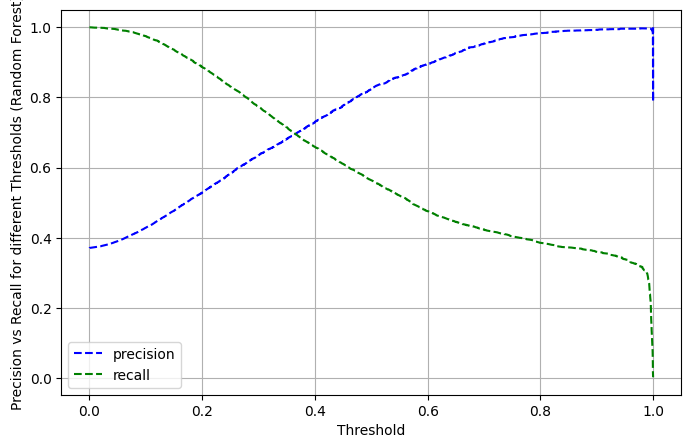

In [47]:
#Get the probabilities (not the 0/1 prediction)
y_val_probs = full_pipeline.predict_proba(X_val)[:,1]

#get the values for the curve
precisions,recalls,thresholds = precision_recall_curve(y_val,y_val_probs)

#plot the curve
plt.figure(figsize=(8,5))
plt.plot(thresholds,precisions[:-1],'b--',label='precision')
plt.plot(thresholds,recalls[:-1],'g--',label='recall')
plt.xlabel('Threshold')
plt.ylabel('Precision vs Recall for different Thresholds (Random Forest)')
plt.legend()
plt.grid()
plt.show()

In [19]:
y_val_probs = full_pipeline.predict_proba(X_val)[:,1]
threshold=0.28
y_val_custom_pred=(y_val_probs >= threshold).astype(int)
print(classification_report(y_val,y_val_custom_pred))

              precision    recall  f1-score   support

           0       0.86      0.71      0.77     15033
           1       0.62      0.80      0.70      8845

    accuracy                           0.74     23878
   macro avg       0.74      0.75      0.73     23878
weighted avg       0.77      0.74      0.74     23878



#### ROC Curve & AUC (The "Model Quality" Metric)
**ROC** stands for Receiver Operating Characteristic. While the PR curve focuses on the "Canceled" class, the ROC curve looks at the global performance of the model.
It plots two things against each other:

True Positive Rate (Recall): Catching the cancellations.
False Positive Rate: How many "Stayed" guests you are accidentally flagging as "Canceled."

**The AUC (Area Under the Curve):**
This is the single most famous number in classification.

AUC = 0.5: Your model is as good as flipping a coin (random).
AUC = 0.8: Your model is doing quite well (where you likely are now).
AUC = 1.0: Perfect model (usually means you have a data leak!).

#### **Hyperparameter Tuning**

**Parameters ($w$ and $b$)**: The model learns these during .fit(). You don't set these; the math finds them.

**Hyperparameters ($C$, $Penalty$, $Solver$)**: These are the "knobs" on the outside of the machine. You (the engineer) set these before the training starts.

##### **1.  C (Regularisation)**

The "Inverse" Relationship:



In [20]:
parameter_grid = {
    'classifier__C': [0.01,0.1,1,10,100],
    'classifier__penalty': ['l2']
}

grid_search = GridSearchCV(full_pipeline,parameter_grid,cv=5,scoring='recall')
grid_search.fit(X_train,y_train)

print(f'Best C found : {grid_search.best_params_}')
print(f'Best Cross-Val Recall : {grid_search.best_score_:4f}')

Best C found : {'classifier__C': 100, 'classifier__penalty': 'l2'}
Best Cross-Val Recall : 0.560413


**param_grid:** - We create a dictionary. The keys must match the name of the step in your pipeline (ours was 'classifier') followed by two underscores __ and then the parameter name. We give it a list of values we want to test.

**cv=5:** - This is the Cross-Validation. The computer splits your X_train into 5 parts. It trains on 4, validates on 1, and repeats this 5 times for every single value in your grid.
        Math: 5 values of $C$ $\times$ 5 folds = 25 total training runs.

**scoring='recall':** - This is the most important part! You are telling the computer: "Don't just look for the highest accuracy. Look for the version of $C$ that gives me the best Recall (catching cancellations)."

**grid_search.fit():** - This is where the heavy lifting happens. It iterates through every combination, runs the cross-validation, and saves the "winner."

**How to combine them (The Professional Flow)**  : You don't choose between GridSearchCV and Threshold Tuning. You do them in order:

**Step 1 (GridSearch):**  Find the best "Math Version" of the model (e.g., $C=100$) using the standard 0.5 threshold.

**Step 2 (Threshold):** Take that "Best Math Version" and slide the threshold down to 0.28 to get the "Business Version" (High Recall).

In [21]:
best_model=grid_search.best_estimator_
y_val_probs_tuned = best_model.predict_proba(X_val)[:,1]
threshold=0.28
y_final_pred = (y_val_probs_tuned >= threshold).astype(int)

print('Final Optimised Model Report (Best C + Custom Threshold) : ')
print(classification_report(y_val,y_final_pred))

Final Optimised Model Report (Best C + Custom Threshold) : 
              precision    recall  f1-score   support

           0       0.86      0.71      0.77     15033
           1       0.62      0.80      0.69      8845

    accuracy                           0.74     23878
   macro avg       0.74      0.75      0.73     23878
weighted avg       0.77      0.74      0.74     23878



**"Are we still using the Pipeline?"**

Yes! This is the beauty of Scikit-Learn.

When you ran grid_search.fit(X_train, y_train), you passed it the full_pipeline.The grid_search.best_estimator_ is not just the Logistic Regression model.It is a complete copy of your pipeline (Preprocessor + Model) with the $C$ value set to 100.So, when you call best_model.predict_proba(X_val), it still scales your numbers and encodes your categories automatically before passing them to the math engine. It’s just a "levelled-up" version of your original pipeline.

**Result we got after C Tuning :**

That is actually a very common and insightful realization. It can feel disappointing when you do all that "heavy lifting" with GridSearchCV only to see the numbers stay the same, but it actually tells us something very important about your data.

Here is why your report didn't move:

**1. The "Plateau" Effect** - In many datasets, especially tabular ones like Hotel Bookings, the relationship between the features and the target is relatively "linear" and simple.

Your Baseline Model ($C=1.0$) was likely already "good enough" to capture the main patterns.
Moving to $C=100$ gave the weights more freedom, but they probably didn't find any "hidden gold." If the signals in your 57 features are clear, Logistic Regression finds them almost immediately.

**2. The Dominance of the Threshold** : 

The Threshold is a much more powerful "lever" than the C parameter.

Changing $C$ slightly adjusts the probabilities (e.g., a guest's probability of canceling moves from $0.32$ to $0.34$).
But since your threshold is $0.28$, both of those values still result in a prediction of "Canceled" (1).Therefore, the final classification (0 or 1) stays exactly the same, and your report doesn't change by even a single decimal point.

**3. Is the model "stuck"?**

It's not stuck; it's saturated. Within the "world" of Logistic Regression, you have likely reached the maximum performance possible with these specific 57 features. To get a better report now, we have to change the inputs or the algorithm, not just the "knobs" ($C$).

#### **Learning Curve**

In machine learning, a learning curve is a diagnostic plot that shows how a model's performance (e.g., accuracy or error/loss) on both the training and validation sets changes with an increasing amount of training data or number of training iterations (epochs). It is used to diagnose issues such as overfitting, underfitting, and to determine if adding more data will improve the model's performance

It answers the three most expensive questions in Data Science:

1. Is my model "too simple" (Underfitting)? If the model is a simple straight line, it doesn't matter if you give it 100,000 rows; it will never get smarter.

2. Is my model "too complex" (Overfitting)? Is it just memorizing the training data but failing on the validation data?

3. Do I need more data? Should the hotel spend money to collect more rows, or is the current 100k+ rows enough?

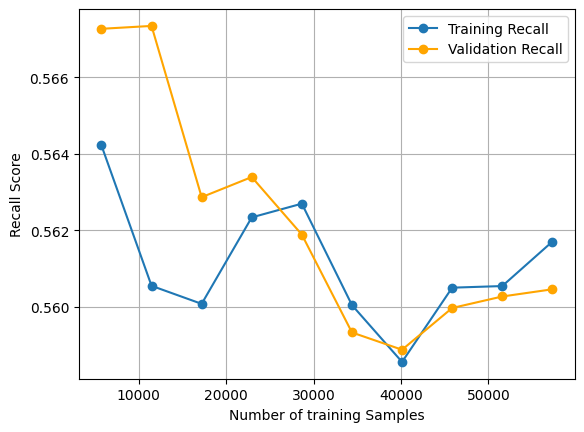

In [30]:
train_sizes,train_scores,val_scores = learning_curve(
    estimator=best_model, #The winning pipeline from GridSearchCV
    X=X_train,  #Raw training feature
    y=y_train,  #Training target
    cv=5,  #5-fold cross-validation for every point on the graph
    scoring='recall', #because we care about recall not only accuracy
    train_sizes= np.linspace(0.1,1.0,10)  # test at 10%,20%,30%....upto 100% of teh data
)

#As there are 5 scores (cv=5) for every training size,We have to take average of each to plot the learning curve.
train_mean=np.mean(train_scores,axis=1)
val_mean=np.mean(val_scores,axis=1)

plt.plot(train_sizes,train_mean,label='Training Recall',marker='o')
plt.plot(train_sizes,val_mean,label='Validation Recall',marker='o',color='orange')
plt.xlabel('Number of training Samples')
plt.ylabel('Recall Score')
plt.legend()
plt.grid(True)
plt.show()


**The "Deep Diagnosis":** 

If we ignore the tiny ripples and look at the "big picture":

    The Lines are Touching: By the time you reach 50,000 samples, the Blue and Orange lines are very close.
    
    The Gap is Closed: This means you have Low Variance (No Overfitting). The model performs almost identically on training data and unseen data.
    
    The Score is Flat: The lines aren't going "Up." They are going "Sideways."
    
**Conclusion:**  Your model has High Bias. It is "saturated." Giving it more data won't help, and tuning $C$ further won't help. The Logistic Regression model is like a student who has learned everything in the textbook but still only gets a 56% because the textbook is missing the "advanced chapters."

### **Feature Engineering** 

Feature Engineering is the process of using domain knowledge to create new variables (features) from raw data that help machine learning algorithms perform better.

The Three Main Techniques are :

    Transformation: Changing the math of a column (e.g., taking the log of a skewed price     column to make it more "Normal")

    Interaction: Combining two columns (e.g., Adults + Children = Total_Guests).

    Binning: Turning a continuous number into a category (e.g., Turning Lead Time into  "Last Minute," "Planned," and "Early Bird").


**When is Feature Engineering done?**

**Phase 1** (Initial FE): Before you ever train a model, you use common sense. You see adults and children, and you immediately create total_guests because it's obvious math.

**Phase 2** (Iterative FE): This is where you are now. You built a model, you looked at the Learning Curve, and you diagnosed High Bias (Underfitting). Now you go back to the lab to create "Smarter Features" to break that plateau.

Does it mess up the Pipeline? Yes, if you do it manually. But if you do it programmatically, no. In a professional workflow, you don't add columns to the CSV and re-save it. Instead, you add a "Feature Engineering Step" at the very beginning of your Pipeline.

**The Professional Code Flow:**

*We will create a function and then update your num_features list.*

In [23]:
def add_custom_features(df):

    # Copy the df first ,because we are creating a new df and don't want to affect original df
    df=df.copy()

    df['total_nights']=df['stays_in_weekend_nights']+df['stays_in_week_nights']
    df['total_cost']=df['adr']*df['total_nights']
    df['total_guests']=df['adults']+df['children']+df['babies']
    df['is_family']=(df['children']+df['babies'] > 0).astype(int)

    return df

In [24]:
# Creating a new dataframe called 'df_engineered' 

df_engineered = add_custom_features(df)

df_engineered.columns

Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
       'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type', 'agent',
       'company', 'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'reservation_status', 'reservation_status_date', 'total_nights',
       'total_cost', 'total_guests', 'is_family'],
      dtype='object')

In [25]:
# Update the feature type list that we created earlier.
num_features_eng = num_features + ['total_nights','total_cost','total_guests']
bin_features_eng = bin_features + ['is_family']

##### Re-Split and Re-Run

As we have created an another df,did some feature engineering(added some columns).
We will now Split the new df 'df_engineered' into train,test and validation set using new names to avoid name clash.

In [26]:
X_eng=df_engineered.drop('is_canceled',axis=1)
y_eng=df_engineered['is_canceled']

X_train_val_eng, X_test_eng,y_train_val_eng,y_test_eng=train_test_split(X_eng,y_eng,test_size=0.2,stratify=y_eng,random_state=42)
X_train_eng,X_val_eng,y_train_eng,y_val_eng=train_test_split(X_train_val_eng,y_train_val_eng,test_size=0.25,stratify=y_train_val_eng,random_state=42)

In [27]:
preprocessor_eng = ColumnTransformer(transformers=[
    ('num',num_pipeline,num_features_eng),
    ('cat',cat_pipeline,cat_features),
    ('bin','passthrough',bin_features_eng)
])

full_pipeline_eng = Pipeline(steps=[
    ('preprocessor',preprocessor_eng),
    ('classifier',LogisticRegression(C=100,random_state=42,max_iter=1000))
])

##### Re-fit the pipeline

As we have now splitted our X_eng and y_eng, SO now we have to fit our X_train_eng and y_train_eng in full pipeline.


In [28]:
full_pipeline_eng.fit(X_train_eng,y_train_eng)

#predicting using new Validation set
y_val_eng_probs=full_pipeline.predict_proba(X_val_eng)[:,1]

threshold=0.28
y_val_custom_pred_eng=(y_val_eng_probs >= threshold).astype(int)

In [29]:
print(classification_report(y_val_eng,y_val_custom_pred_eng))

              precision    recall  f1-score   support

           0       0.84      0.74      0.79     15033
           1       0.63      0.77      0.69      8845

    accuracy                           0.75     23878
   macro avg       0.74      0.75      0.74     23878
weighted avg       0.76      0.75      0.75     23878



**Why did Recall decrease? (The Math)**

When we add features like total_cost, you are giving the Logistic Regression more "certainty."

The "Old" Model: It was a bit "sloppy." It saw a high adr and guessed "Cancel!" quite easily, which caught a lot of cancellations (High Recall) but also made a lot of mistakes (Lower Precision).

The "New" Model: It’s now "smarter" but more "cautious." With total_cost, it realizes that some guests pay a high rate but only stay for 1 night, so they are actually less likely to cancel than someone staying 7 nights.

**Time for the "Heavy Artillery" : Random Forest**

If you want to see that Recall go back to $0.80+$ AND keep that higher Precision, we need an algorithm that can handle "Non-Linear" logic.

**Logistic Regression** (Current): "I will draw a straight line through the data."

**Random Forest (Next)**: "I will build 100 different decision trees that ask complex questions like: 'Is the lead time > 100 AND is the total cost > $500 AND are there children? If yes, 90% chance of cancellation.'"

## **Random Forest**

#### **Prerequisite** :

1. Concept of purity of nodes.
2. Gini Impurity or Entropy Function. $$G = 1 - \sum_{i=1}^{n} (P_i)^2$$
3. Information gain (Reduction of entropy).
4. Overfitting trap of Decision tree.


Because a tree is so "greedy" for purity, it will keep splitting until every single "Leaf" has only 1 guest in it.

It will find a rule like: "If the guest is from Germany AND booked on a Tuesday AND has 1 child AND ordered a chicken sandwich... they will cancel."
This is 100% Pure, but it’s a "coincidence," not a "pattern." This is Overfitting.

To master the code later, you need to know these "Stop Signs" (Hyperparameters):

1. max_depth: "Don't grow more than X levels deep."
2. min_samples_split: "Don't split a node unless it has at least X guests."
3. min_samples_leaf: "A final decision (leaf) must represent at least X guests.
   

##### **Ensembling trees to form Random Forest**

The Random Forest is built on a concept called Bagging (Bootstrap Aggregating). This is the secret sauce that stops the "memorization" (Overfitting) problem.
1. **The "Bootstrap" (Random Samples)** :

_Instead of giving every tree the exact same 100,000 hotel bookings, the Random Forest does this:_

        It creates "New" datasets by sampling with replacement.

        If you have guests [A, B, C], a Bootstrap sample might be [A, A, C]. It's the same size as the original, but some guests are repeated and some are left out.

        Mastery Tip: About 33% of your data is left out of each tree. This is called Out-of-Bag (OOB) data. The forest uses this to test itself!

3. **The "Random" in Random Forest (Feature Subsets)** :

_If Deposit Type is a super-strong feature, every single tree will pick it as the root node. Then all your trees will look exactly the same! That's not a "Forest," that's just the same tree 100 times._

To fix this, Random Forest adds a rule:

    When a tree wants to split a node, it is only allowed to look at a random subset of features (usually $\sqrt{\text{total features}}$).

    If your hotel data has 57 features, each split might only be allowed to choose from 7 or 8 random columns.

    This forces the trees to "notice" other patterns (like lead_time or total_guests) that they would usually ignore.


3. **The Power of "Voting"**:

_When it's time to predict if a guest will cancel:_

    Tree 1 says: Cancel (1)

    Tree 2 says: Stay (0)

    Tree 3 says: Cancel (1)

    ... (up to Tree 100)

Final Result: The Forest takes the majority vote.

**Why this kills Overfitting:**
One tree might overfit because it saw a "weird" guest from Germany. But the other 99 trees likely didn't see that specific weird guest, or they weren't allowed to look at the "Country" feature for that split. The "weirdness" gets cancelled out by the majority.

#### **Hyperparameters** :

let's look at the "Big Four" hyperparameters you will be tuning in Scikit-Learn:

| Hyperparameter | What it controls | Analogy |
| :--- | :--- | :--- |
| **n_estimators** | Number of trees in the forest. | How many experts are in the room? |
| **max_depth** | How deep each tree can grow. | How "specific" or "obsessive" can each expert be? |
| **max_features** | Size of the random subset of features. | How many "clues" is each expert allowed to see? |
| **min_samples_leaf** | Minimum guests required to be in a leaf. | Do we allow a "rule" based on just 1 person? |

| Hyperparameter | High Value effect | Low value effect |
| :--- | :-- | :-- |
| **n_estimators** | Better performance, but slower. | Faster, but "noisy" predictions. |
| **max_depth** | Risk of Overfitting (Trees are too deep) | Risk of Underfitting (Trees are too simple) |
| **min_samples_leaf** | Smoother, more general rules | Jagged, overly specific rules. |

### **Implementing code** 

NOTE : As for Logistic regression implementation, we already have dataset splitted into train,test and val set , we will use thes split that we have done for feature engineering.
We only have to define new Preprocsessor and new Pipeline for random Forest, followed by finding best C , Hyperparameter tuning and model Evaluation.

In [31]:
# Some new imports for implementing Random Forest.
from sklearn.ensemble import RandomForestClassifier

#### **The Redefined Preprocessor**

_**Decision Trees don't care about scaling.**_

Remember how we had to use StandardScaler for Logistic Regression because Lead Time (0–300) was so much bigger than Adults (0–4)?

A Decision Tree doesn't care if a number is 0.001 or 1,000,000.

It's only asking: "Is it bigger or smaller than this threshold?" * Because of this, the "math weight" of a large number doesn't "bully" the smaller numbers.

In [32]:
num_transformer_rf = Pipeline(steps=[
    ('imputer',SimpleImputer(strategy='median'))
])

cat_transformer_rf = Pipeline(steps=[
    ('imputer',SimpleImputer(strategy='constant',fill_value='missing')),
    ('onehot',OneHotEncoder(handle_unknown='ignore'))
])

#Combining sub pipelines into a new preprocessor.

preprocessor_rf = ColumnTransformer(transformers=[
    ('num',num_transformer_rf,num_features_eng),
    ('cat',cat_transformer_rf,cat_features),
    ('bin','passthrough',bin_features_eng)
])

#### **The Baseline Pipeline**

Now, we define the "Forest" engine. We will call this full_pipeline_rf. We will start with a "safe" max_depth so it doesn't run for 3 hours!

In [34]:
full_pipeline_rf = Pipeline(steps=[
    ('preprocessor',preprocessor_rf),
    ('classifier',RandomForestClassifier(
        n_estimators=100,
        max_depth=10,
        random_state=42,
        n_jobs=-1
    ))
])

#fit the model
full_pipeline_rf.fit(X_train_eng,y_train_eng)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


**Note on n_jobs=-1** : This is a cool trick for Random Forest. Since every tree is independent, your computer can build them all at the same time using all its "brains" (cores). Logistic Regression couldn't do this!

In [35]:
# The first 'forest' Report.
# Let's see if the baseline (with default 0.5 threshold ) already beats our model.

y_val_pred_rf = full_pipeline_rf.predict(X_val_eng)

print('Baseline Random Forest (Threshold = 0.5) report :')
print(classification_report(y_val_eng,y_val_pred_rf))

Baseline Random Forest (Threshold = 0.5) report :
              precision    recall  f1-score   support

           0       0.74      1.00      0.85     15033
           1       0.98      0.41      0.58      8845

    accuracy                           0.78     23878
   macro avg       0.86      0.70      0.72     23878
weighted avg       0.83      0.78      0.75     23878



**Observation** : The Precision-Recall Extremity
The baseline Random Forest with a default threshold (0.5) yielded an exceptional Precision of 0.98 but a poor Recall of 0.41.

**Analysis** : This indicates the model is highly conservative. It only identifies a booking as "Canceled" when the evidence is overwhelming. While we can trust its positive predictions almost 100%, we are missing over half of the actual cancellations. This is likely due to the class imbalance and the model's "greedy" nature for purity.

**Strategy** : We must adjust the decision threshold to find a better balance. By lowering the threshold, we will allow the model to be less "certain" before flagging a cancellation, which should significantly boost Recall while sacrificing some of this nearly-perfect Precision.

#### **Precision-Recall Curve** :
Before finding best threshold for the model,
let's visualize the "Trade-off." We are going to plot a curve that shows us exactly what happens to Precision as Recall goes up. This will help us find the "Sweet Spot" (maybe where Recall hits 0.80).

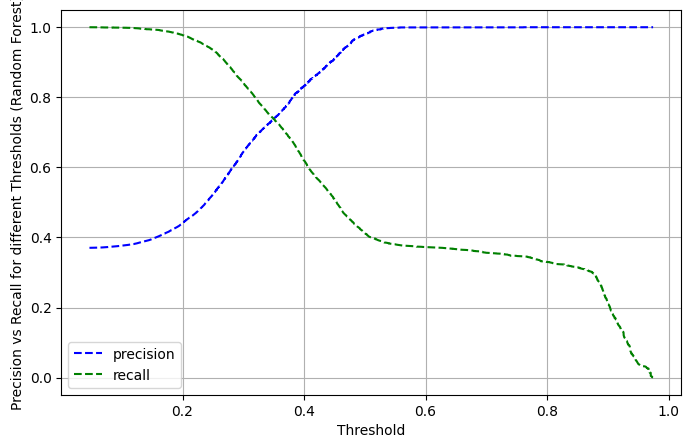

In [45]:
#Get the probabilities (not the 0/1 prediction)
y_val_probs_rf = full_pipeline_rf.predict_proba(X_val_eng)[:,1]

#get the values for the curve
precisions,recalls,thresholds = precision_recall_curve(y_val_eng,y_val_probs_rf)

#plot the curve
plt.figure(figsize=(8,5))
plt.plot(thresholds,precisions[:-1],'b--',label='precision')
plt.plot(thresholds,recalls[:-1],'g--',label='recall')
plt.xlabel('Threshold')
plt.ylabel('Precision vs Recall for different Thresholds (Random Forest)')
plt.legend()
plt.grid()
plt.show()

As we can see from the Precision vs recall against threshold graph ,
for threshold = 0.40 $\rightarrow$ Recall 0.83, Precision 0.62.

Is it good? Yes! For a hotel, catching 83% of cancellations while still being right 62% of the time is a massive upgrade over your previous model.

However, look at how "jagged" the lines were. That jaggedness means the model is a bit "shaky." If we tune the hyperparameters, we can make those lines smoother and push them higher.

Our goal for the Hyperparameter Tuning: To find a forest where, at the same 0.83 Recall, the Precision is 0.70 or higher.

#### Code Explanation (Tricky)

why [;,-1] is used in precision and recall ?

This is a very common point of confusion.

The precision_recall_curve function returns arrays of different lengths. If there are $N$ unique probability thresholds, it returns:

    Thresholds: N values.
    Precision/Recall: N+1 values (it adds a 0 and 1 at the end to "close" the graph).

If you try to plot $N$ thresholds against $N+1$ precision values, Python will throw an error. By using precision[:-1], we are saying: "Ignore the very last value so the lengths match." It has nothing to do with reverse order!

#### **The Professional Sequence**
We do not change the threshold right now. If we set it to $0.40$ now and then tune the model, that $0.40$ might become a bad choice for the new version.

**Step A** : Keep threshold at default ($0.5$).

**Step B**: Run GridSearchCV to find the best "Structural" parameters ($max\_depth$, etc.).

**Step C** : Take that "Best Model" and re-run the Threshold Plot.

**Step D** : Pick the final threshold for the final report.

#### **Hyperparameter Tuning**

We are going to search for the "Big Three" that impact Overfitting and Diversity.

Important Note: In GridSearchCV, we refer to the parameters by the name we gave them in the Pipeline, followed by two underscores __. Since our model is named classifier, we use classifier__.

In [54]:
param_grid = {
    'classifier__n_estimators':[100,200],   # Number of Expert (tree)
    'classifier__max_depth':[10,20],  # How obsessive they are
    'classifier__min_samples_leaf':[1,4]  # Controls overfitting at the tips
}

grid_search = GridSearchCV(
    estimator=full_pipeline_rf,
    param_grid=param_grid,
    cv=3,  # 3-Fold cross- validation.
    scoring='f1',  # we want best balance of Precision and recall
    n_jobs=-1,  # Using all CPU cores
    verbose=2  # Shows us the progress while searching is running, so we don't get bored
    #and feels like we are doing something cool... haha
)

In [55]:
grid_search.fit(X_train_eng,y_train_eng)

print('Best Parameter Found : ',grid_search.best_params_)
print("Best F1 Score from Grid Search : ",grid_search.best_score_)

Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best Parameter Found :  {'classifier__max_depth': 20, 'classifier__min_samples_leaf': 1, 'classifier__n_estimators': 100}
Best F1 Score from Grid Search :  0.7497758671804454


#### Hyperparameter Tuning Result:

The GridSearchCV identified max_depth: 20 and min_samples_leaf: 1 as the optimal configuration. The F1-score of 0.75 is a significant improvement over the Logistic Regression baseline (~0.60). This suggests that the non-linear nature of the Random Forest is much better suited to capturing the complex relationships in the hotel booking data (like the interaction between lead time and deposit type) that the linear model missed.


#### **Hyperparameter Updating/Implementing**

As through Hyperparameter tuning, we got best hyperparameter value.

**As Professional Workflow** - We have to update the hyperparameter in the original (previous) pipeline, So that final model become clean and precise. BUT..

**In Professional Data Science Notebook** - We are telling a story. If we just overwrite our old variables, the reader (or your future self) won't see the "Redemption Arc" of our model.

SO,

By creating a new tuned Pipeline '_full_pipeline_rf_tuned_', we preserve the "Baseline" results above it for a clear comparison.

In [71]:
full_pipeline_rf_tuned = Pipeline(steps=[
    ('preprocessor',preprocessor_rf),
    ('classifier',RandomForestClassifier(
        n_estimators=100,
        max_depth=20,
        random_state=42,
        n_jobs=-1,
        min_samples_leaf=1
    ))
])

#fit the model
full_pipeline_rf_tuned.fit(X_train_eng,y_train_eng)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


#### Threshold Tuning

As threshold = 0.37 was the best for old model when we didn't apply hyperparameter tuning.
The Tuned Model is a different beast—it has different probability distributions, and its "Sweet Spot" will definitely be in a different place.

To get the Tuned Precision-Recall Curve , we have to plot P-R curve again but using 'full_pipeline_rf_tuned'.

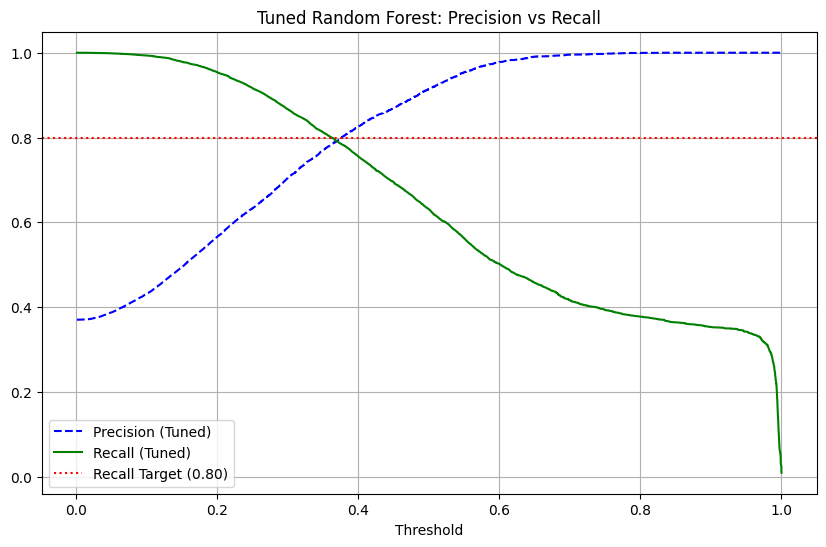

In [59]:
#Get probabilities from your TUNED master model
y_val_probs_tuned = full_pipeline_rf_tuned.predict_proba(X_val_eng)[:, 1]

# 2. Generate the NEW curve data
prec_t, rec_t, thresh_t = precision_recall_curve(y_val_eng, y_val_probs_tuned)

# 3. Plot it to find the NEW Sweet Spot
plt.figure(figsize=(10, 6))
plt.plot(thresh_t, prec_t[:-1], "b--", label="Precision (Tuned)")
plt.plot(thresh_t, rec_t[:-1], "g-", label="Recall (Tuned)")
plt.axhline(0.80, color='red', linestyle=':', label='Recall Target (0.80)')
plt.xlabel("Threshold")
plt.title("Tuned Random Forest: Precision vs Recall")
plt.legend()
plt.grid()
plt.show()

From the P-R curve, its clearly implied that using threshold = 0.37 will still be best for maintaining the balance between Precision and Recall.

#### **Updating Threshold and Predicting based on it**

In [66]:
y_val_probs_final = full_pipeline_rf_tuned.predict_proba(X_val_eng)[:,1]
final_threshold = 0.37
y_val_final_pred = (y_val_probs_final >= final_threshold).astype(int)

In [67]:
print(f"--- FINAL TUNED RANDOM FOREST REPORT ---")
print(f"Hyperparameters: Depth 20, Leaf 1 | Threshold: {final_threshold}")
print(classification_report(y_val_eng, y_val_final_pred))

--- FINAL TUNED RANDOM FOREST REPORT ---
Hyperparameters: Depth 20, Leaf 1 | Threshold: 0.37
              precision    recall  f1-score   support

           0       0.88      0.88      0.88     15033
           1       0.79      0.79      0.79      8845

    accuracy                           0.85     23878
   macro avg       0.83      0.83      0.83     23878
weighted avg       0.85      0.85      0.85     23878



0.79 Precision and 0.79 Recall for the "Canceled" class is a beautiful sight.
It is exactly what a high-performing, well-tuned model looks like.


#### **Final Model Validation:**

The tuned Random Forest, utilizing an optimized threshold of 0.37, achieved a balanced Precision and Recall of 0.79 for the cancellation class (Class 1). This is a substantial improvement over the baseline Logistic Regression, which struggled with a heavy trade-off.

**Business Impact** : With an overall accuracy of 85%, the hotel can now confidently predict 4 out of 5 cancellations. This allows for aggressive overbooking strategies and targeted retention campaigns with minimal risk of misclassifying legitimate guests.

### **Feature Importance:**

We can plot which features (like lead_time or total_cost) the forest used most to make these 85% accurate decisions.


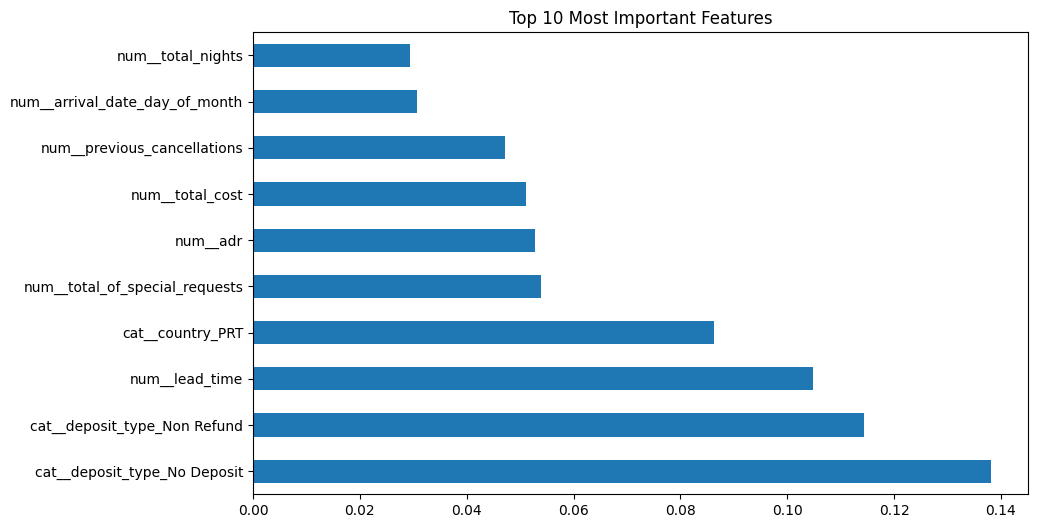

In [69]:
# Get the feature names from the preprocessing steps
# This assumes your pipeline has a 'preprocessor' step that handles transformations
preprocessor = full_pipeline_rf_tuned.named_steps['preprocessor']
feature_names = preprocessor.get_feature_names_out()  # For sklearn >= 1.0

# Extract the importance from the classifier step of the pipeline
importances = full_pipeline_rf_tuned.named_steps['classifier'].feature_importances_

# Create a Series for easy plotting
feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False)

# Plot the Top 10
feat_imp.head(10).plot(kind='barh', figsize=(10,6))
plt.title("Top 10 Most Important Features")
plt.show()

## **The Final Test - Prediction on Test Set**

**Validation Set** : This is what we used for the "Battle Royale" (tuning). We used it to pick the best depth and threshold. Because we "looked" at it to make decisions, the model is slightly biased toward it.

**Test Set** (The "Vault"): This set has been sitting in the dark, untouched.

### The Rule:

#### You only run the Test Set ONCE.
Think of it like a final exam. You don't use the final exam to study (that's validation); you take the final exam only when you are 100% sure your model is ready. If you get a good score on the Test Set, it proves your model can handle unseen data in the real world.

In [70]:
# 1. Get probabilities for the TEST set (The unseen data)
y_test_probs = full_pipeline_rf_tuned.predict_proba(X_test_eng)[:, 1]

# 2. Apply our 'Winning Threshold' from the validation phase
test_threshold = 0.37
y_test_pred = (y_test_probs >= test_threshold).astype(int)

# 3. Generate the Final Performance Report
print("--- FINAL TEST SET PERFORMANCE (THE ULTIMATE TRUTH) ---")
print(f"Threshold used: {test_threshold}")
print(classification_report(y_test_eng, y_test_pred))

--- FINAL TEST SET PERFORMANCE (THE ULTIMATE TRUTH) ---
Threshold used: 0.37
              precision    recall  f1-score   support

           0       0.88      0.88      0.88     15033
           1       0.80      0.79      0.80      8845

    accuracy                           0.85     23878
   macro avg       0.84      0.84      0.84     23878
weighted avg       0.85      0.85      0.85     23878



#### **Eureka !!! We did it**

Getting 0.80 Precision and 0.79 Recall on the Test Set is the "Gold Standard" in Machine Learning.
It means our model didn't just memorize the training data -- it actually learned the underlying patterns of human behavior. Since your Test scores are almost identical to our Validation scores , we have Zero Overfitting,

**We have built a robust,'Production-Ready' model !!**

In [73]:
import joblib

# ==========================================
# 1. THE "FREEZE": SAVE THE MASTER MODEL
# ==========================================
# This saves the entire pipeline (preprocessor + tuned RF) to your disk
joblib.dump(full_pipeline_rf_tuned, 'hotel_cancellation_master_v1.pkl')
print("✅ Success: Master Model saved as 'hotel_cancellation_master_v1.pkl'")


loaded_model = joblib.load('hotel_cancellation_master_v1.pkl')

def predict_hotel_cancellation(guest_data_dict, threshold=0.37):
    # Convert input to DataFrame
    df_new = pd.DataFrame([guest_data_dict])
    
    # --- THE IMPORTANT PART ---
    # We need to ensure df_new has EVERY column the model saw at fit time.
    # We fill missing columns with a neutral value (0 or "Unknown")
    for col in X_train_eng.columns:
        if col not in df_new.columns:
            df_new[col] = 0  # Or "Unknown" if it's categorical
    
    # Reorder columns to match original training data exactly
    df_new = df_new[X_train_eng.columns]
    
    # Now the pipeline will be happy!
    cancel_prob = loaded_model.predict_proba(df_new)[:, 1][0]
    is_canceled = 1 if cancel_prob >= threshold else 0
    
    return "WILL CANCEL" if is_canceled == 1 else "WILL NOT CANCEL"
# 2. Test with the full required columns
# (In a real app, you'd pull these from your UI form)
print(predict_hotel_cancellation(sample_guest))

✅ Success: Master Model saved as 'hotel_cancellation_master_v1.pkl'
WILL CANCEL
